# 07 — Analytical Inverse Kinematics for a 2-Link Planar Arm

**Section:** Manipulation · **Mirrors MATLAB:** *Inverse Kinematics*

For a planar 2-link arm with link lengths $l_1$, $l_2$ and end-effector position $(x, y)$:

$$\cos\theta_2 = \frac{x^2 + y^2 - l_1^2 - l_2^2}{2 l_1 l_2}$$

$$\theta_1 = \arctan2(y, x) - \arctan2(l_2 \sin\theta_2,\ l_1 + l_2 \cos\theta_2)$$

The choice of $+\arccos$ vs $-\arccos$ for $\theta_2$ selects the **elbow-up** or **elbow-down** branch.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

l1, l2 = 1.0, 1.0


def fk(theta):
    th1, th2 = theta
    p1 = np.array([l1 * np.cos(th1), l1 * np.sin(th1)])
    p2 = p1 + np.array([l2 * np.cos(th1 + th2), l2 * np.sin(th1 + th2)])
    return p1, p2


def ik(target, elbow_up=True):
    x, y = target
    r2 = x * x + y * y
    c2 = np.clip((r2 - l1 ** 2 - l2 ** 2) / (2 * l1 * l2), -1, 1)
    th2 = np.arccos(c2) if elbow_up else -np.arccos(c2)
    th1 = np.arctan2(y, x) - np.arctan2(l2 * np.sin(th2), l1 + l2 * np.cos(th2))
    return np.array([th1, th2])


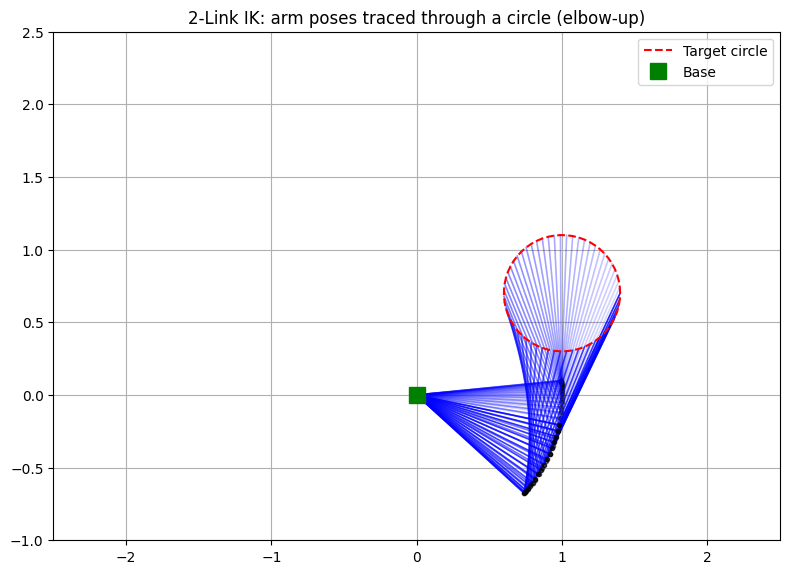

In [2]:
# Trace a circular trajectory
N = 60
phi = np.linspace(0, 2 * np.pi, N)
targets = np.column_stack([1.0 + 0.4 * np.cos(phi), 0.7 + 0.4 * np.sin(phi)])

fig, ax = plt.subplots(figsize=(8, 8))
for k, t in enumerate(targets):
    theta = ik(t)
    p1, p2 = fk(theta)
    a = 0.15 + 0.7 * (k / N)
    ax.plot([0, p1[0], p2[0]], [0, p1[1], p2[1]], 'b-', alpha=a, lw=1.2)
    ax.plot(p1[0], p1[1], 'ko', markersize=3, alpha=a)

ax.plot(targets[:, 0], targets[:, 1], 'r--', lw=1.5, label='Target circle')
ax.plot(0, 0, 'gs', markersize=12, label='Base')
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-1.0, 2.5)
ax.set_aspect('equal'); ax.grid(); ax.legend()
ax.set_title('2-Link IK: arm poses traced through a circle (elbow-up)')
plt.tight_layout()
plt.show()
